Задание 1. 

Задача 1.

In [ ]:
import torch

class BatchNorm:
    def __init__(self, num_features, eps=1e-5, momentum=0.1, affine=True, track_running_stats=True, device=None, dtype=None):
        assert num_features > 0
        self.num_features = num_features
        self.eps = eps
        self.momentum = momentum
        self.affine = affine
        self.track_running_stats = track_running_stats

        # Параметры (γ, β)
        if affine:
            self.weight = torch.ones(num_features, device=device, dtype=dtype, requires_grad=True)  
            self.bias   = torch.zeros(num_features, device=device, dtype=dtype, requires_grad=True) 
        else:
            self.weight = None
            self.bias   = None

        # Скользящие статистики
        if track_running_stats:
            self.running_mean = torch.zeros(num_features, device=device, dtype=dtype)
            self.running_var  = torch.ones(num_features, device=device, dtype=dtype)
            self.num_batches_tracked = 0
        else:
            self.running_mean = None
            self.running_var  = None
            self.num_batches_tracked = None

        self.training = True

    def train(self): self.training = True;  return self
    def eval(self):  self.training = False; return self

    def _bshape(self, x):
        return (1, self.num_features) + (1,) * (x.dim() - 2)

    def _reduce_dims(self, x):
        return [0] + list(range(2, x.dim()))

    def forward(self, x: torch.Tensor):
        if x.dim() < 2:
            raise ValueError("Ожидается тензор формы (N, C, ...).")
        if x.shape[1] != self.num_features:
            raise ValueError(f"num_features={self.num_features}, а пришло C={x.shape[1]}.")

        red = self._reduce_dims(x)
        bsh = self._bshape(x)

        if self.training:
            mean = x.mean(dim=red)                               
            var  = ((x - mean.view(bsh))**2).mean(dim=red)        

            if self.track_running_stats:
                with torch.no_grad():
                    self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * mean
                    self.running_var  = (1 - self.momentum) * self.running_var  + self.momentum * var
                    self.num_batches_tracked += 1
        else:
            if not self.track_running_stats:
                raise RuntimeError("Eval без track_running_stats невозможен.")
            mean, var = self.running_mean, self.running_var

        x_hat = (x - mean.view(bsh)) / torch.sqrt(var.view(bsh) + self.eps)

        if self.affine:
            y = x_hat * self.weight.view(bsh) + self.bias.view(bsh)
        else:
            y = x_hat
        return y

    def parameters(self):
        return [p for p in (self.weight, self.bias) if p is not None]

    @torch.no_grad()
    def reset_running_stats(self):
        if self.track_running_stats:
            self.running_mean.zero_()
            self.running_var.fill_(1.0)
            self.num_batches_tracked = 0

    @torch.no_grad()
    def reset_parameters(self):
        if self.affine:
            self.weight.fill_(1.0)
            self.bias.zero_()
        self.reset_running_stats()

    def __call__(self, x): 
        return self.forward(x)



Проверка

In [ ]:
if __name__ == "__main__":
    torch.manual_seed(0)
    device = "cpu"  

    N, C, H, W = 32, 8, 16, 16

    x = torch.randn(N, C, H, W, device=device)
    bn_plain = BatchNorm(C, affine=False, track_running_stats=True).train()
    y = bn_plain(x)

    red = [0, 2, 3]
    mean_per_c = y.mean(dim=red)               
    var_per_c  = y.var(dim=red, unbiased=False)
    print("TRAIN affine=False: max|mean| =", mean_per_c.abs().max().item())
    print("TRAIN affine=False: mean|var-1| =", (var_per_c - 1).abs().mean().item())


    bn_eval = BatchNorm(C, affine=False, track_running_stats=True).train()
    for _ in range(10):
        xb = torch.randn(N, C, H, W, device=device)
        _ = bn_eval(xb) 

    bn_eval.eval()
    x_new = torch.randn(N, C, H, W, device=device)
    y_eval = bn_eval(x_new)
    mean_eval = y_eval.mean(dim=red)
    var_eval  = y_eval.var(dim=red, unbiased=False)
    print("EVAL affine=False: max|mean| ≈", mean_eval.abs().max().item())
    print("EVAL affine=False: mean|var-1| ≈", (var_eval - 1).abs().mean().item())

    bn_aff = BatchNorm(C, affine=True, track_running_stats=True).train()
    x3 = torch.randn(N, C, H, W, device=device, requires_grad=False)
    y3 = bn_aff(x3)
    loss = (y3 ** 2).mean()  
    loss.backward()

    print("grad gamma  mean abs:", bn_aff.weight.grad.abs().mean().item())
    print("grad beta   mean abs:", (bn_aff.bias.grad.abs().mean().item()))

    # Ручной SGD
    lr = 1e-2
    with torch.no_grad():
        for p in bn_aff.parameters():
            if p.grad is not None:
                p -= lr * p.grad
                p.grad.zero_()

    CHECK_WITH_NN = False
    if CHECK_WITH_NN:
        import torch.nn as nn  
        bn_ref = nn.BatchNorm2d(C, eps=1e-5, momentum=0.1, affine=True, track_running_stats=True)
        bn_ref.train()

        with torch.no_grad():
            bn_ref.running_mean.zero_()
            bn_ref.running_var.fill_(1.0)

        x_ref = torch.randn(N, C, H, W)
        y_impl = BatchNorm(C, affine=True, track_running_stats=True).train()(x_ref)
        y_ref  = bn_ref(x_ref)

        print("Сравнение с nn.BatchNorm2d (train): L_inf =", (y_impl - y_ref).abs().max().item())


TRAIN affine=False: max|mean| = 1.5745172277092934e-08
TRAIN affine=False: mean|var-1| = 1.0006129741668701e-05
EVAL affine=False: max|mean| ≈ 0.01244618371129036
EVAL affine=False: mean|var-1| ≈ 0.010190926492214203
grad gamma  mean abs: 0.24999749660491943
grad beta   mean abs: 2.5438566808588803e-09


Задача 2

In [ ]:
import math
import torch

class Linear:

    def __init__(self, in_features, out_features, bias=True, device=None, dtype=None):
        assert in_features > 0 and out_features > 0
        self.in_features = in_features
        self.out_features = out_features
        self.bias_flag = bias

        self.weight = torch.empty(out_features, in_features, device=device, dtype=dtype, requires_grad=True)
        self.bias = torch.empty(out_features, device=device, dtype=dtype, requires_grad=True) if bias else None

        self.reset_parameters()

    def reset_parameters(self):
        fan_in = self.in_features
        bound_w = math.sqrt(6.0 / fan_in) 
        with torch.no_grad():
            self.weight.uniform_(-bound_w, bound_w)
            if self.bias is not None:
                bound_b = 1.0 / math.sqrt(fan_in)
                self.bias.uniform_(-bound_b, bound_b)

    def forward(self, x: torch.Tensor):
        if x.shape[-1] != self.in_features:
            raise ValueError(f"Ожидалось последнее измерение={self.in_features}, но пришло {x.shape[-1]}")

        y = x.matmul(self.weight.t())
        if self.bias is not None:
            y = y + self.bias  
        return y

    def __call__(self, x):
        return self.forward(x)

    def parameters(self):
        return [p for p in (self.weight, self.bias) if p is not None]

    def to(self, device=None, dtype=None):
        if device is not None:
            self.weight = self.weight.to(device)
            if self.bias is not None: self.bias = self.bias.to(device)
        if dtype is not None:
            self.weight = self.weight.to(dtype=dtype)
            if self.bias is not None: self.bias = self.bias.to(dtype=dtype)
        return self


Проверка

In [ ]:
if __name__ == "__main__":
    torch.manual_seed(0)
    device = "cpu"

    N, T, in_f, out_f = 32, 10, 16, 7
    x = torch.randn(N, T, in_f, device=device)

    lin = Linear(in_f, out_f, bias=True, device=device)

    y = lin(x) 

    # Простой лосс и градиенты
    loss = (y ** 2).mean()
    loss.backward()

    print("grad W mean abs:", lin.weight.grad.abs().mean().item())
    if lin.bias is not None:
        print("grad b mean abs:", lin.bias.grad.abs().mean().item())

    # Ручной SGD-шаг
    lr = 1e-2
    with torch.no_grad():
        for p in lin.parameters():
            p -= lr * p.grad
            p.grad.zero_()

    CHECK_WITH_NN = False
    if CHECK_WITH_NN:
        import torch.nn as nn
        ref = nn.Linear(in_f, out_f, bias=True)
        with torch.no_grad():
            ref.weight.copy_(lin.weight)
            ref.bias.copy_(lin.bias)
        y_ref = ref(x)
        print("L_inf(diff with nn.Linear):", (y - y_ref).abs().max().item())


grad W mean abs: 0.09244364500045776
grad b mean abs: 0.06451241672039032


Задача 3.

In [9]:
import torch

class Dropout:

    def __init__(self, p: float = 0.5, inplace: bool = False):
        if not (0.0 <= p < 1.0):
            raise ValueError("p должен быть в [0, 1). При p=1 обучение не имеет смысла.")
        self.p = float(p)
        self.inplace = bool(inplace)
        self.training = True

    def train(self):
        self.training = True
        return self

    def eval(self):
        self.training = False
        return self

    def forward(self, x: torch.Tensor):
        if not self.training or self.p == 0.0:
            return x if self.inplace else x.clone()

        keep_prob = 1.0 - self.p
        mask = (torch.rand_like(x) < keep_prob).to(dtype=x.dtype)
        if self.inplace:
            x.mul_(mask).div_(keep_prob)
            return x
        else:
            return x * mask / keep_prob

    def __call__(self, x):
        return self.forward(x)

    def parameters(self):
        return [] 

    def to(self, device=None, dtype=None):
        return self


Проверка

In [ ]:
if __name__ == "__main__":
    torch.manual_seed(0)

    N, D = 10000, 16
    x = torch.randn(N, D)

    p = 0.3
    dp = Dropout(p=p, inplace=False).train()

    y = dp(x)

    drop_fraction = (y == 0).float().mean().item()

    mean_x = x.mean().item()
    mean_y = y.mean().item()

    print(f"p = {p}")
    print("Empirical drop fraction ≈", round(drop_fraction, 4))
    print("mean(x) =", round(mean_x, 6), "   mean(y) ≈", round(mean_y, 6))

    x_req = x.clone().requires_grad_(True)
    y2 = dp(x_req)  
    loss = (y2 ** 2).mean()
    loss.backward()
    print("grad exists:", x_req.grad is not None, "   grad mean abs:", float(x_req.grad.abs().mean()))

    CHECK_WITH_NN = False
    if CHECK_WITH_NN:
        import torch.nn as nn
        ref = nn.Dropout(p=p)
        ref.train()
        torch.manual_seed(0) 
        y_ref = ref(x)
        torch.manual_seed(0)
        y_impl = Dropout(p=p).train()(x)
        print("L_inf(diff with nn.Dropout):", float((y_impl - y_ref).abs().max()))


p = 0.3
Empirical drop fraction ≈ 0.2988
mean(x) = -0.002276    mean(y) ≈ -0.002551
grad exists: True    grad mean abs: 1.4239140909921844e-05


Задача 4. {*}

ReLU

In [ ]:
class ReLU:
    def __init__(self, inplace: bool = False):
        self.inplace = bool(inplace)
        self.training = True  

    def train(self): self.training = True;  return self
    def eval(self):  self.training = False; return self

    def forward(self, x: torch.Tensor):
        if self.inplace:
            return x.clamp_min_(0)  
        else:
            return x.clamp_min(0)

    def __call__(self, x): return self.forward(x)
    def parameters(self): return []
    def to(self, device=None, dtype=None): return self

Sigmoid

In [ ]:
class Sigmoid:
    def __init__(self):
        self.training = True

    def train(self): self.training = True;  return self
    def eval(self):  self.training = False; return self

    def forward(self, x: torch.Tensor):
        return 1.0 / (1.0 + torch.exp(-x))

    def __call__(self, x): return self.forward(x)
    def parameters(self): return []
    def to(self, device=None, dtype=None): return self

Softmax

In [ ]:
class Softmax:
    def __init__(self, dim: int = -1):
        self.dim = dim
        self.training = True

    def train(self): self.training = True;  return self
    def eval(self):  self.training = False; return self

    def forward(self, x: torch.Tensor):
        dim = self.dim if self.dim is not None else -1
        # численно устойчивая версия
        x_max = x.max(dim=dim, keepdim=True).values
        exps = torch.exp(x - x_max)
        return exps / exps.sum(dim=dim, keepdim=True)

    def __call__(self, x): return self.forward(x)
    def parameters(self): return []
    def to(self, device=None, dtype=None): return self

Проверка

In [ ]:
if __name__ == "__main__":
    torch.manual_seed(0)
    x = torch.randn(4, 5, requires_grad=True)

    # ReLU
    relu = ReLU(inplace=False)
    y_relu = relu(x)
    loss_relu = y_relu.mean()
    loss_relu.backward(retain_graph=True)
    print("[ReLU] out >= 0:", bool((y_relu >= 0).all()))
    print("[ReLU] grad mean abs:", float(x.grad.abs().mean()))
    x.grad.zero_()

    # Sigmoid
    sig = Sigmoid()
    y_sig = sig(x)
    loss_sig = (y_sig**2).mean()
    loss_sig.backward(retain_graph=True)
    print("[Sigmoid] in (0,1):", bool(((y_sig > 0) & (y_sig < 1)).all()))
    print("[Sigmoid] grad mean abs:", float(x.grad.abs().mean()))
    x.grad.zero_()

    # Softmax
    sm = Softmax(dim=-1)
    y_sm = sm(x)
    sums = y_sm.sum(dim=-1)
    loss_sm = -(y_sm[:, 0]).mean()  
    loss_sm.backward()
    print("[Softmax] sums ≈ 1:", float((sums - 1).abs().max()))
    print("[Softmax] grad mean abs:", float(x.grad.abs().mean()))

[ReLU] out >= 0: True
[ReLU] grad mean abs: 0.030000001192092896
[Sigmoid] in (0,1): True
[Sigmoid] grad mean abs: 0.010715178214013577
[Softmax] sums ≈ 1: 0.0
[Softmax] grad mean abs: 0.007814086973667145


Задание 2. {*}

In [ ]:
import torch

def reflect_pad_2d_asym(x: torch.Tensor, top: int, bottom: int, left: int, right: int) -> torch.Tensor:
    H, W = x.shape[-2], x.shape[-1]
    dev = x.device

    def take_h(idx):
        return x.index_select(-2, idx)

    def take_w(t, idx):
        return t.index_select(-1, idx)

    # по высоте
    if top > 0:
        top_idx = torch.arange(1, top + 1, device=dev).flip(0)               
        x = torch.cat([take_h(top_idx), x], dim=-2)
    if bottom > 0:
        bot_idx = H - 2 - torch.arange(0, bottom, device=dev)            
        x = torch.cat([x, take_h(bot_idx)], dim=-2)

    # по ширине
    if left > 0:
        left_idx = torch.arange(1, left + 1, device=dev).flip(0)
        x = torch.cat([take_w(x, left_idx), x], dim=-1)
    if right > 0:
        right_idx = W - 2 - torch.arange(0, right, device=dev)
        x = torch.cat([x, take_w(x, right_idx)], dim=-1)

    return x

def median_filter2d(x: torch.Tensor, k: int) -> torch.Tensor:
    if k <= 0:
        raise ValueError("k должно быть положительным.")

    squeeze_back = (x.dim() == 2)
    if squeeze_back:
        x = x.unsqueeze(0).unsqueeze(0)  
    elif x.dim() != 4:
        raise ValueError("Ожидаются формы (H,W) или (N,C,H,W).")

    N, C, H, W = x.shape

    r = k // 2
    top = left = r - 1 if (k % 2 == 0) else r
    bottom = right = r

    x_pad = reflect_pad_2d_asym(x, top, bottom, left, right) 

    patches = x_pad.unfold(-2, k, 1).unfold(-2, k, 1)         
    kk = k * k
    patches = patches.contiguous().view(N, C, H, W, kk)   

    if kk % 2 == 1:
        out = patches.kthvalue(kk // 2 + 1, dim=-1).values
    else:
        lo = patches.kthvalue(kk // 2,     dim=-1).values
        hi = patches.kthvalue(kk // 2 + 1, dim=-1).values
        out = 0.5 * (lo + hi)

    return out[0, 0] if squeeze_back else out


if __name__ == "__main__":
    torch.manual_seed(0)
    H, W = 128, 128

    yy = torch.linspace(-1, 1, H).view(H, 1).expand(H, W)
    xx = torch.linspace(-1, 1, W).view(1, W).expand(H, W)
    clean = (0.5*(xx+1) + 0.5*(1-yy**2)).clamp(0, 1)

    rnd = torch.rand(H, W)
    noisy = clean.clone()
    p_sp = 0.30
    noisy[rnd < p_sp/2] = 0.0
    noisy[rnd > 1 - p_sp/2] = 1.0

    for k in (3, 5, 10):
        out = median_filter2d(noisy, k)
        mae = (out - clean).abs().mean().item()
        print(f"k={k:>2}  MAE: {mae:.6f}   shape={tuple(out.shape)}")


k= 3  MAE: 0.009868   shape=(128, 128)
k= 5  MAE: 0.003242   shape=(128, 128)
k=10  MAE: 0.005965   shape=(128, 128)


Задание 3.

In [ ]:
from __future__ import annotations
from typing import List, Union
import random
import math

import torch
from PIL import Image, ImageDraw

# -------------------- Base --------------------
class BaseTransform:
    def __init__(self, p: float):
        if not (0.0 <= p <= 1.0):
            raise ValueError("p must be in [0, 1]")
        self.p = float(p)
        self.rng = random.Random()

    def set_seed(self, seed: int) -> "BaseTransform":
        self.rng.seed(seed)
        return self

    def __call__(self, img: Image.Image) -> Image.Image:
        if self.rng.random() < self.p:
            return self.apply(img)
        return img

    def apply(self, img: Image.Image) -> Image.Image:
        raise NotImplementedError


# -------------------- RandomCrop --------------------
class RandomCrop(BaseTransform):
    def __init__(self, p: float, **kwargs):
        super().__init__(p)
        self.size = kwargs.get("size", None)

    def apply(self, img: Image.Image) -> Image.Image:
        W, H = img.size
        if self.size is None:
            s = int(0.8 * min(W, H))
            th, tw = s, s
        elif isinstance(self.size, int):
            th = tw = self.size
        else:
            th, tw = int(self.size[0]), int(self.size[1])

        th = max(1, min(th, H))
        tw = max(1, min(tw, W))
        if H == th and W == tw:
            return img

        top = self.rng.randrange(0, H - th + 1)
        left = self.rng.randrange(0, W - tw + 1)
        crop = img.crop((left, top, left + tw, top + th))
        return crop.resize((W, H), resample=Image.BICUBIC)


# -------------------- RandomRotate --------------------
class RandomRotate(BaseTransform):
    def __init__(self, p: float, **kwargs):
        super().__init__(p)
        deg = kwargs.get("degrees", (-15.0, 15.0))
        if isinstance(deg, (int, float)):
            self.degrees = (-float(deg), float(deg))
        else:
            self.degrees = (float(deg[0]), float(deg[1]))
        self.fill = kwargs.get("fill", None)   
        self.expand = False

    def apply(self, img: Image.Image) -> Image.Image:
        lo, hi = self.degrees
        angle = lo + (hi - lo) * self.rng.random()
        kwargs = dict(resample=Image.BICUBIC, expand=self.expand)
        if self.fill is not None:
            kwargs["fillcolor"] = self.fill
        return img.rotate(angle, **kwargs)


# -------------------- RandomZoom --------------------
class RandomZoom(BaseTransform):
    def __init__(self, p: float, **kwargs):
        super().__init__(p)
        z = kwargs.get("zoom_range", (0.8, 1.2))
        self.zoom_range = (float(z[0]), float(z[1]))
        self.fill = kwargs.get("fill", 0)

    def apply(self, img: Image.Image) -> Image.Image:
        W, H = img.size
        zmin, zmax = self.zoom_range
        z = zmin + (zmax - zmin) * self.rng.random()

        if math.isclose(z, 1.0, rel_tol=1e-6, abs_tol=1e-6):
            return img

        if z > 1.0:
            crop_w = max(1, int(round(W / z)))
            crop_h = max(1, int(round(H / z)))
            left = (W - crop_w) // 2
            top = (H - crop_h) // 2
            crop = img.crop((left, top, left + crop_w, top + crop_h))
            return crop.resize((W, H), resample=Image.BICUBIC)
        else:
            new_w = max(1, int(round(W * z)))
            new_h = max(1, int(round(H * z)))
            small = img.resize((new_w, new_h), resample=Image.BICUBIC)
            canvas = Image.new(img.mode, (W, H), color=self.fill)
            off_x = (W - new_w) // 2
            off_y = (H - new_h) // 2
            canvas.paste(small, (off_x, off_y))
            return canvas


# -------------------- ToTensor --------------------
class ToTensor:
    """
    PIL.Image -> torch.Tensor (C,H,W), float32, значения [0,1].
    Без устаревшего TypedStorage.
    """
    def __call__(self, img: Image.Image) -> torch.Tensor:
        if not isinstance(img, Image.Image):
            raise TypeError("ToTensor ожидает PIL.Image")

        if img.mode not in ("RGB", "L", "LA", "RGBA", "F", "I"):
            img = img.convert("RGB")

        buf = img.tobytes()
        try:
           byte_tensor = torch.frombuffer(buf, dtype=torch.uint8).clone()  
        except Exception:
           byte_tensor = torch.tensor(memoryview(buf), dtype=torch.uint8)   


        H, W = img.height, img.width
        nchan = len(img.getbands())
        byte_tensor = byte_tensor.view(H, W, nchan).permute(2, 0, 1).contiguous()
        return byte_tensor.to(dtype=torch.float32) / 255.0


# -------------------- Compose --------------------
class Compose:
    def __init__(self, transforms: List[Union(BaseTransform, ToTensor)]):
        if not isinstance(transforms, list) or not transforms:
            raise ValueError("Compose ожидает непустой список трансформаций")
        self.transforms = transforms

    def set_seed(self, seed: int) -> "Compose":
        for i, t in enumerate(self.transforms):
            if isinstance(t, BaseTransform):
                t.set_seed(seed + i)
        return self

    def __call__(self, img: Image.Image, seed: int | None = None):
        if seed is not None:
            for i, t in enumerate(self.transforms):
                if isinstance(t, BaseTransform):
                    t.set_seed(seed + i)

        out = img
        for t in self.transforms:
            out = t(out)
        return out


#Проверки
 if __name__ == "__main__":
    torch.manual_seed(0)

    # 1) Синтетическое изображение
    W = H = 128
    img = Image.new("RGB", (W, H), "black")
    draw = ImageDraw.Draw(img)
    for y in range(H):
        shade = int(255 * y / (H - 1))
        draw.line([(0, y), (W, y)], fill=(shade, 128, 255 - shade))
    draw.ellipse((32, 32, 96, 96), outline="white", width=2)

    # 2) Пайплайн
    pipeline = Compose([
        RandomCrop(p=0.9, size=96),
        RandomRotate(p=0.9, degrees=(-20, 20), fill=(0, 0, 0)),
        RandomZoom(p=0.9, zoom_range=(0.8, 1.3), fill=(0, 0, 0)),
        ToTensor()
    ])

    # --- Воспроизводимость ---
    t1 = pipeline(img, seed=123)
    t2 = pipeline(img, seed=123)
    print("Reproducible:", bool(torch.allclose(t1, t2)))

    # --- Результат ---
    print("Output tensor shape:", tuple(t1.shape),
          "dtype:", t1.dtype,
          "range:", float(t1.min()), "…", float(t1.max()))

    # --- Граничные случаи ---
    # p=0
    no_aug = Compose([RandomRotate(p=0.0, degrees=30), ToTensor()])
    base_tensor = ToTensor()(img)
    print("p=0 no-op equals:", bool(torch.allclose(no_aug(img, seed=0), base_tensor)))

    # p=1 и size > image
    always_crop = Compose([RandomCrop(p=1.0, size=(200, 200)), ToTensor()])
    y = always_crop(img, seed=42)
    print("p=1 applied, shape:", tuple(y.shape))

    degenerate = Compose([
        RandomRotate(p=1.0, degrees=(0, 0)),
        RandomZoom(p=1.0, zoom_range=(1.0, 1.0)),
        ToTensor()
    ])
    z = degenerate(img, seed=1)
    print("degenerate equals original:", bool(torch.allclose(z, base_tensor)))


Reproducible: True
Output tensor shape: (3, 128, 128) dtype: torch.float32 range: 0.03921568766236305 … 1.0
p=0 no-op equals: True
p=1 applied, shape: (3, 128, 128)
degenerate equals original: True


Задание 4.

Using: cpu

=== Scenario: baseline ===
epoch  1/15 | train 0.5087/0.819 | test 0.3900/0.859
epoch  2/15 | train 0.3169/0.886 | test 0.3141/0.888
epoch  3/15 | train 0.2705/0.901 | test 0.2825/0.897
epoch  4/15 | train 0.2402/0.912 | test 0.2679/0.901
epoch  5/15 | train 0.2179/0.920 | test 0.2556/0.909
epoch  6/15 | train 0.1973/0.927 | test 0.2440/0.914
epoch  7/15 | train 0.1820/0.934 | test 0.2465/0.910
epoch  8/15 | train 0.1685/0.938 | test 0.2242/0.921
epoch  9/15 | train 0.1519/0.944 | test 0.2434/0.912
epoch 10/15 | train 0.1359/0.950 | test 0.2327/0.919
epoch 11/15 | train 0.1241/0.955 | test 0.2291/0.926
epoch 12/15 | train 0.1096/0.960 | test 0.2441/0.922
epoch 13/15 | train 0.0986/0.963 | test 0.2586/0.917
epoch 14/15 | train 0.0888/0.968 | test 0.2628/0.919
epoch 15/15 | train 0.0756/0.973 | test 0.2689/0.922

=== Scenario: light ===
epoch  1/15 | train 0.6477/0.757 | test 0.4178/0.847
epoch  2/15 | train 0.4622/0.826 | test 0.3603/0.870
epoch  3/15 | train 0.4023/0.849 | 

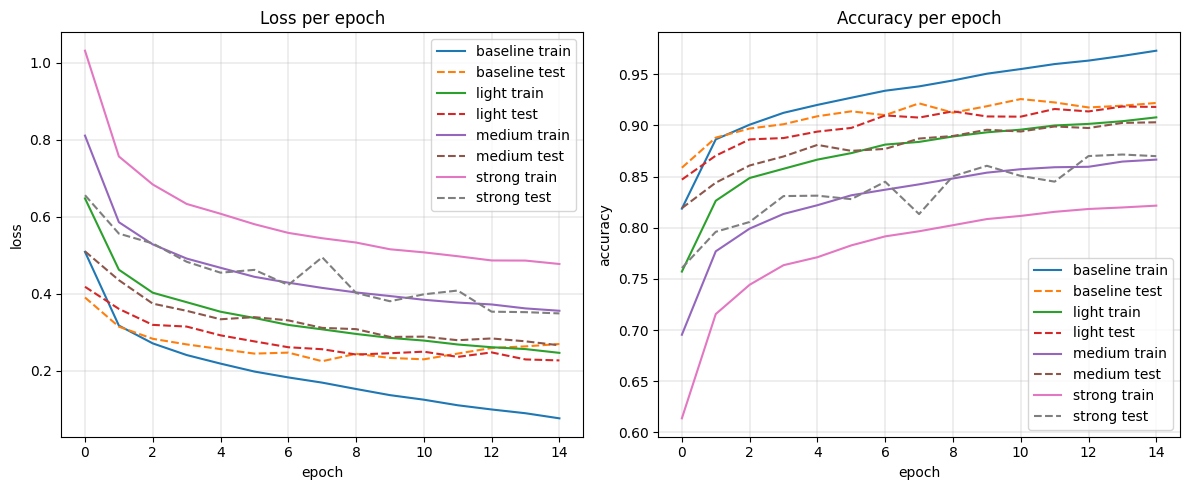

In [ ]:

from __future__ import annotations
from typing import List, Union, Dict
import random, math
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from PIL import Image
import matplotlib.pyplot as plt

class BaseTransform:
    def __init__(self, p: float):
        if not (0.0 <= p <= 1.0): raise ValueError("p must be in [0,1]")
        self.p = float(p)
        self.rng = random.Random()
    def set_seed(self, seed: int): self.rng.seed(seed); return self
    def __call__(self, img: Image.Image) -> Image.Image:
        return self.apply(img) if self.rng.random() < self.p else img
    def apply(self, img: Image.Image) -> Image.Image: raise NotImplementedError

class RandomCrop(BaseTransform):
    def __init__(self, p: float, **kw):
        super().__init__(p)
        self.size = kw.get("size", None)
    def apply(self, img: Image.Image) -> Image.Image:
        W, H = img.size
        if self.size is None:
            s = int(0.8 * min(W, H)); th, tw = s, s
        elif isinstance(self.size, int):
            th = tw = self.size
        else:
            th, tw = int(self.size[0]), int(self.size[1])
        th = max(1, min(th, H)); tw = max(1, min(tw, W))
        if (H, W) == (th, tw): return img
        top  = self.rng.randrange(0, H - th + 1)
        left = self.rng.randrange(0, W - tw + 1)
        crop = img.crop((left, top, left + tw, top + th))
        return crop.resize((W, H), resample=Image.BICUBIC)

class RandomRotate(BaseTransform):
    def __init__(self, p: float, **kw):
        super().__init__(p)
        deg = kw.get("degrees", (-15.0, 15.0))
        self.degrees = (-float(deg), float(deg)) if isinstance(deg,(int,float)) else (float(deg[0]), float(deg[1]))
        self.fill = kw.get("fill", 0); self.expand=False
    def apply(self, img: Image.Image) -> Image.Image:
        lo, hi = self.degrees
        angle = lo + (hi - lo) * self.rng.random()
        kwargs = dict(resample=Image.BICUBIC, expand=self.expand)
        if self.fill is not None: kwargs["fillcolor"] = self.fill
        return img.rotate(angle, **kwargs)

class RandomZoom(BaseTransform):
    def __init__(self, p: float, **kw):
        super().__init__(p)
        z = kw.get("zoom_range", (0.9, 1.1))
        self.zoom_range = (float(z[0]), float(z[1]))
        self.fill = kw.get("fill", 0)
    def apply(self, img: Image.Image) -> Image.Image:
        W, H = img.size
        zmin, zmax = self.zoom_range
        z = zmin + (zmax - zmin) * self.rng.random()
        if math.isclose(z, 1.0, rel_tol=1e-6, abs_tol=1e-6):
            return img
        if z > 1.0:
            cw, ch = max(1,int(round(W/z))), max(1,int(round(H/z)))
            left, top = (W-cw)//2, (H-ch)//2
            return img.crop((left, top, left+cw, top+ch)).resize((W,H), Image.BICUBIC)
        else:
            nw, nh = max(1,int(round(W*z))), max(1,int(round(H*z)))
            small = img.resize((nw,nh), Image.BICUBIC)
            canvas = Image.new(img.mode, (W,H), color=self.fill)
            canvas.paste(small, ((W-nw)//2, (H-nh)//2))
            return canvas

class ToTensor:
    def __call__(self, img: Image.Image) -> torch.Tensor:
        if img.mode not in ("L","RGB","RGBA","LA","F","I"):
            img = img.convert("RGB")
        buf = img.tobytes()
        try:
            bt = torch.frombuffer(buf, dtype=torch.uint8).clone()  
        except Exception:
            bt = torch.tensor(memoryview(buf), dtype=torch.uint8)
        H, W = img.height, img.width
        C = len(img.getbands())
        return bt.view(H, W, C).permute(2,0,1).contiguous().float() / 255.0

class Compose:
    def __init__(self, transforms: List[Union[BaseTransform, ToTensor]]):
        assert isinstance(transforms, list) and transforms, "Compose expects non-empty list"
        self.transforms = transforms
    def set_seed(self, seed: int):
        for i,t in enumerate(self.transforms):
            if isinstance(t, BaseTransform): t.set_seed(seed+i)
        return self
    def __call__(self, img: Image.Image, seed: int | None=None):
        if seed is not None: self.set_seed(seed)
        out = img
        for t in self.transforms: out = t(out)
        return out

class TransformWrapper:
    def __init__(self, comp: Compose): self.comp = comp
    def __call__(self, img): return self.comp(img)

class SmallCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1,32,3,padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(64*7*7, 128), nn.ReLU(inplace=True),
            nn.Linear(128, num_classes)
        )
    def forward(self,x): return self.net(x)

def accuracy(logits, y): return (logits.argmax(1)==y).float().mean().item()

@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    crit = nn.CrossEntropyLoss()
    tot_loss=0.0; tot_acc=0.0; n=0
    for xb,yb in loader:
        xb,yb = xb.to(device), yb.to(device)
        out = model(xb); loss = crit(out,yb)
        b = xb.size(0)
        tot_loss += loss.item()*b
        tot_acc  += (out.argmax(1)==yb).float().sum().item()
        n += b
    return tot_loss/n, tot_acc/n

def train_model(model, train_loader, test_loader, device, epochs=15, lr=1e-3, seed_per_epoch=True, train_transform_compose:Compose|None=None):
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss()
    hist = {"train_loss":[], "train_acc":[], "test_loss":[], "test_acc":[]}
    for epoch in range(1, epochs+1):
        model.train()
        if seed_per_epoch and train_transform_compose is not None:
            train_transform_compose.set_seed(12345 + epoch*31)

        run_loss=0.0; run_correct=0; seen=0
        for xb,yb in train_loader:
            xb,yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            out = model(xb)
            loss = crit(out,yb)
            loss.backward(); opt.step()
            b = xb.size(0)
            run_loss += loss.item()*b
            run_correct += (out.argmax(1)==yb).float().sum().item()
            seen += b
        tr_loss = run_loss/seen
        tr_acc  = run_correct/seen
        te_loss, te_acc = evaluate(model, test_loader, device)
        hist["train_loss"].append(tr_loss); hist["train_acc"].append(tr_acc)
        hist["test_loss"].append(te_loss);  hist["test_acc"].append(te_acc)
        print(f"epoch {epoch:>2}/{epochs} | train {tr_loss:.4f}/{tr_acc:.3f} | test {te_loss:.4f}/{te_acc:.3f}")
    return hist

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using:", device)

def make_transform_scenarios() -> Dict[str, Compose]:
    baseline = Compose([ToTensor()]) 

    light = Compose([
        RandomCrop(0.5, size=24),
        RandomRotate(0.3, degrees=15, fill=0),
        RandomZoom(0.3, zoom_range=(0.9,1.1), fill=0),
        ToTensor()
    ])

    medium = Compose([
        RandomCrop(0.8, size=22),
        RandomRotate(0.5, degrees=20, fill=0),
        RandomZoom(0.5, zoom_range=(0.85,1.15), fill=0),
        ToTensor()
    ])

    strong = Compose([
        RandomCrop(0.9, size=20),
        RandomRotate(0.9, degrees=25, fill=0),
        RandomZoom(0.9, zoom_range=(0.8,1.2), fill=0),
        ToTensor()
    ])
    return {"baseline": baseline, "light": light, "medium": medium, "strong": strong}

def make_loaders(train_transform: Compose, test_transform: Compose, batch_size=128):
    train_ds = datasets.FashionMNIST(
        root="data", train=True,  download=True,
        transform=TransformWrapper(train_transform)
    )
    test_ds  = datasets.FashionMNIST(
        root="data", train=False, download=True,
        transform=TransformWrapper(test_transform)
    )

    train_loader = DataLoader(
        train_ds, batch_size=batch_size, shuffle=True,
        num_workers=0, pin_memory=False, persistent_workers=False
    )
    test_loader  = DataLoader(
        test_ds,  batch_size=batch_size, shuffle=False,
        num_workers=0, pin_memory=False, persistent_workers=False
    )
    return train_ds, test_ds, train_loader, test_loader



# Запуск экспериментов
EPOCHS = 15
results = {}
scenarios = make_transform_scenarios()

for name, tr in scenarios.items():
    print("\n=== Scenario:", name, "===")
    _, _, train_loader, test_loader = make_loaders(tr, Compose([ToTensor()]))
    model = SmallCNN()
    hist = train_model(model, train_loader, test_loader, device,
                       epochs=EPOCHS, lr=1e-3,
                       seed_per_epoch=True, train_transform_compose=tr)
    results[name] = hist


plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
for name,h in results.items():
    plt.plot(h["train_loss"], label=f"{name} train")
    plt.plot(h["test_loss"],  linestyle="--", label=f"{name} test")
plt.title("Loss per epoch"); plt.xlabel("epoch"); plt.ylabel("loss")
plt.legend(); plt.grid(True, linewidth=0.3)

plt.subplot(1,2,2)
for name,h in results.items():
    plt.plot(h["train_acc"], label=f"{name} train")
    plt.plot(h["test_acc"],  linestyle="--", label=f"{name} test")
plt.title("Accuracy per epoch"); plt.xlabel("epoch"); plt.ylabel("accuracy")
plt.legend(); plt.grid(True, linewidth=0.3)
plt.tight_layout(); plt.show()
